# DermaXplain - Data Preprocessing Notebook

This notebook defines the **core preprocessing pipeline** for DermaXplain.

## Objectives

- load the inventory manifests produced by `01_data_inventory.ipynb`
- define reusable image and mask preprocessing helpers
- verify binary mask handling
- define resizing rules for images and masks
- define normalisation for CNN input
- visually verify resized image/mask alignment
- extract lesion geometry features from segmentation masks
- save enriched manifests for later modelling and XAI notebooks


Further experimental branches should go into a separate notebook such as:
`01_preprocessing_experiments.ipynb`


In [10]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)


In [11]:
# Adjust if notebook location changes
ROOT = Path(".").resolve().parent if Path(".").resolve().name == "src" else Path(".").resolve()

DATA_DIR = ROOT / "data"
MANIFEST_DIR = DATA_DIR / "preprocessed_manifests"
OUT_DIR = DATA_DIR / "preprocessed_manifests"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ISIC_DIR = DATA_DIR / "isic2018"
ISIC_IMG_DIR = ISIC_DIR / "images"
ISIC_MASK_DIR = ISIC_DIR / "masks"

HAM_DIR = DATA_DIR / "ham10000"
HAM_IMG_DIR = HAM_DIR / "images"
HAM_MASK_DIR = HAM_DIR / "masks"

ISIC_MANIFEST = MANIFEST_DIR / "isic2018_inventory.csv"
HAM_MANIFEST = MANIFEST_DIR / "ham10000_inventory.csv"

assert ISIC_MANIFEST.exists(), f"Missing manifest: {ISIC_MANIFEST.resolve()}"
assert HAM_MANIFEST.exists(), f"Missing manifest: {HAM_MANIFEST.resolve()}"

print("Using manifests:")
print("-", ISIC_MANIFEST.resolve())
print("-", HAM_MANIFEST.resolve())


Using manifests:
- /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/preprocessed_manifests/isic2018_inventory.csv
- /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/preprocessed_manifests/ham10000_inventory.csv


## 1. Load manifests

The inventory notebook should already have created one row per image with:
- path matching information
- size checks
- mask coverage
- border-touch diagnostics
- metadata linkage for HAM10000


In [12]:

isic_df = pd.read_csv(ISIC_MANIFEST)
ham_df = pd.read_csv(HAM_MANIFEST)

if "lesion_id" not in ham_df.columns:
    raise ValueError(
        "HAM inventory does not contain lesion_id. "
        "Run the updated 01_data_inventory_lesion_id.ipynb first."
    )

if ham_df["lesion_id"].isna().any():
    raise ValueError("HAM inventory contains missing lesion_id values.")

print("ISIC shape:", isic_df.shape)
print("HAM shape :", ham_df.shape)
print("HAM unique images :", ham_df["stem"].nunique())
print("HAM unique lesions:", ham_df["lesion_id"].nunique())

display(isic_df.head())
display(ham_df[["stem", "lesion_id", "dx", "label_name"]].head())


ISIC shape: (2594, 19)
HAM shape : (10015, 23)
HAM unique images : 10015
HAM unique lesions: 7470


,stem,image_exists,mask_exists,img_h,img_w,pixels,aspect_ratio,mask_h,mask_w,mask_coverage,mask_pixels,mask_size_class,same_size,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched
0,ISIC_0000000,True,True,767,1022,783874,1.332464,767,1022,0.469732,368211,normal,True,False,False,False,False,False,0
1,ISIC_0000001,True,True,767,1022,783874,1.332464,767,1022,0.070504,55266,normal,True,False,False,False,False,False,0
2,ISIC_0000003,True,True,767,1022,783874,1.332464,767,1022,0.336569,263828,normal,True,False,False,False,False,False,0
3,ISIC_0000004,True,True,767,1022,783874,1.332464,767,1022,0.344974,270416,normal,True,False,False,False,False,False,0
4,ISIC_0000006,True,True,767,1022,783874,1.332464,767,1022,0.091723,71899,normal,True,False,False,False,False,False,0


,stem,lesion_id,dx,label_name
0,ISIC_0024306,HAM_0000550,nv,non-melanoma
1,ISIC_0024307,HAM_0003577,nv,non-melanoma
2,ISIC_0024308,HAM_0001477,nv,non-melanoma
3,ISIC_0024309,HAM_0000484,nv,non-melanoma
4,ISIC_0024310,HAM_0003350,mel,melanoma


In [13]:

# Keep only rows with both image and mask present and the same dimensions.
# All metadata columns, including lesion_id, are retained.
isic_core = isic_df.loc[
    isic_df["image_exists"] & isic_df["mask_exists"] & isic_df["same_size"]
].copy()

ham_core = ham_df.loc[
    ham_df["image_exists"] & ham_df["mask_exists"] & ham_df["same_size"]
].copy()

assert "lesion_id" in ham_core.columns
assert ham_core["lesion_id"].notna().all()

print("ISIC usable rows:", len(isic_core))
print("HAM usable rows :", len(ham_core))
print("HAM usable unique lesions:", ham_core["lesion_id"].nunique())


ISIC usable rows: 2594
HAM usable rows : 10015
HAM usable unique lesions: 7470


## 2. Helper functions


In [14]:
# 1- Load image and mask from disk
def load_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)


def load_mask_gray(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("L"))

# 2- Convert grayscale mask to binary (0 and 1)
def to_mask_bin(mask_gray: np.ndarray) -> np.ndarray:
    return (mask_gray > 0).astype(np.uint8)

# 3- Overlay binary mask on RGB image for visualisation (red color with alpha blending)
def overlay_mask(img_rgb: np.ndarray, mask_bin: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    out = img_rgb.copy().astype(np.float32)
    color = np.zeros_like(out)
    color[..., 0] = 255  # red
    lesion = mask_bin.astype(bool)
    out[lesion] = (1 - alpha) * out[lesion] + alpha * color[lesion]
    return out.astype(np.uint8)

# 4- Image resizing

## Use bilinear interpolation for RGB images to maintain visual quality
def resize_image_rgb(img_rgb: np.ndarray, size=(224, 224)) -> np.ndarray:
    return np.array(Image.fromarray(img_rgb).resize(size, Image.Resampling.BILINEAR))

## Use nearest neighbor for masks to preserve binary nature
def resize_mask_bin(mask_bin: np.ndarray, size=(224, 224)) -> np.ndarray:
    mask_img = Image.fromarray((mask_bin * 255).astype(np.uint8))
    mask_resized = mask_img.resize(size, Image.Resampling.NEAREST)
    return (np.array(mask_resized) > 0).astype(np.uint8)

## 5- Normalisation for pretrained models, e.g. ResNet, EfficientNet, etc.
## mean and std from ImageNet, as commonly used for pretrained models
def normalize_imagenet(img_rgb: np.ndarray) -> np.ndarray:
    x = img_rgb.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return (x - mean) / std


## 3. Binary mask handling

Masks may be stored as grayscale PNG images. For geometry and evaluation work we convert them to a clean binary representation.


In [15]:
def sample_triplet(df: pd.DataFrame, img_dir: Path, mask_dir: Path, n: int = 4, random_state: int = 42):
    sample = df.sample(min(n, len(df)), random_state=random_state)
    fig, axes = plt.subplots(len(sample), 3, figsize=(12, 4 * len(sample)))

    if len(sample) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(sample.iterrows()):
        stem = row["stem"]
        img = load_rgb(img_dir / f"{stem}.jpg")
        mask_gray = load_mask_gray(mask_dir / f"{stem}.png")
        mask_bin = to_mask_bin(mask_gray)
        overlay = overlay_mask(img, mask_bin)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{stem} - image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_gray, cmap="gray")
        axes[i, 1].set_title("original mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f"binary overlay (coverage={mask_bin.mean():.3f})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


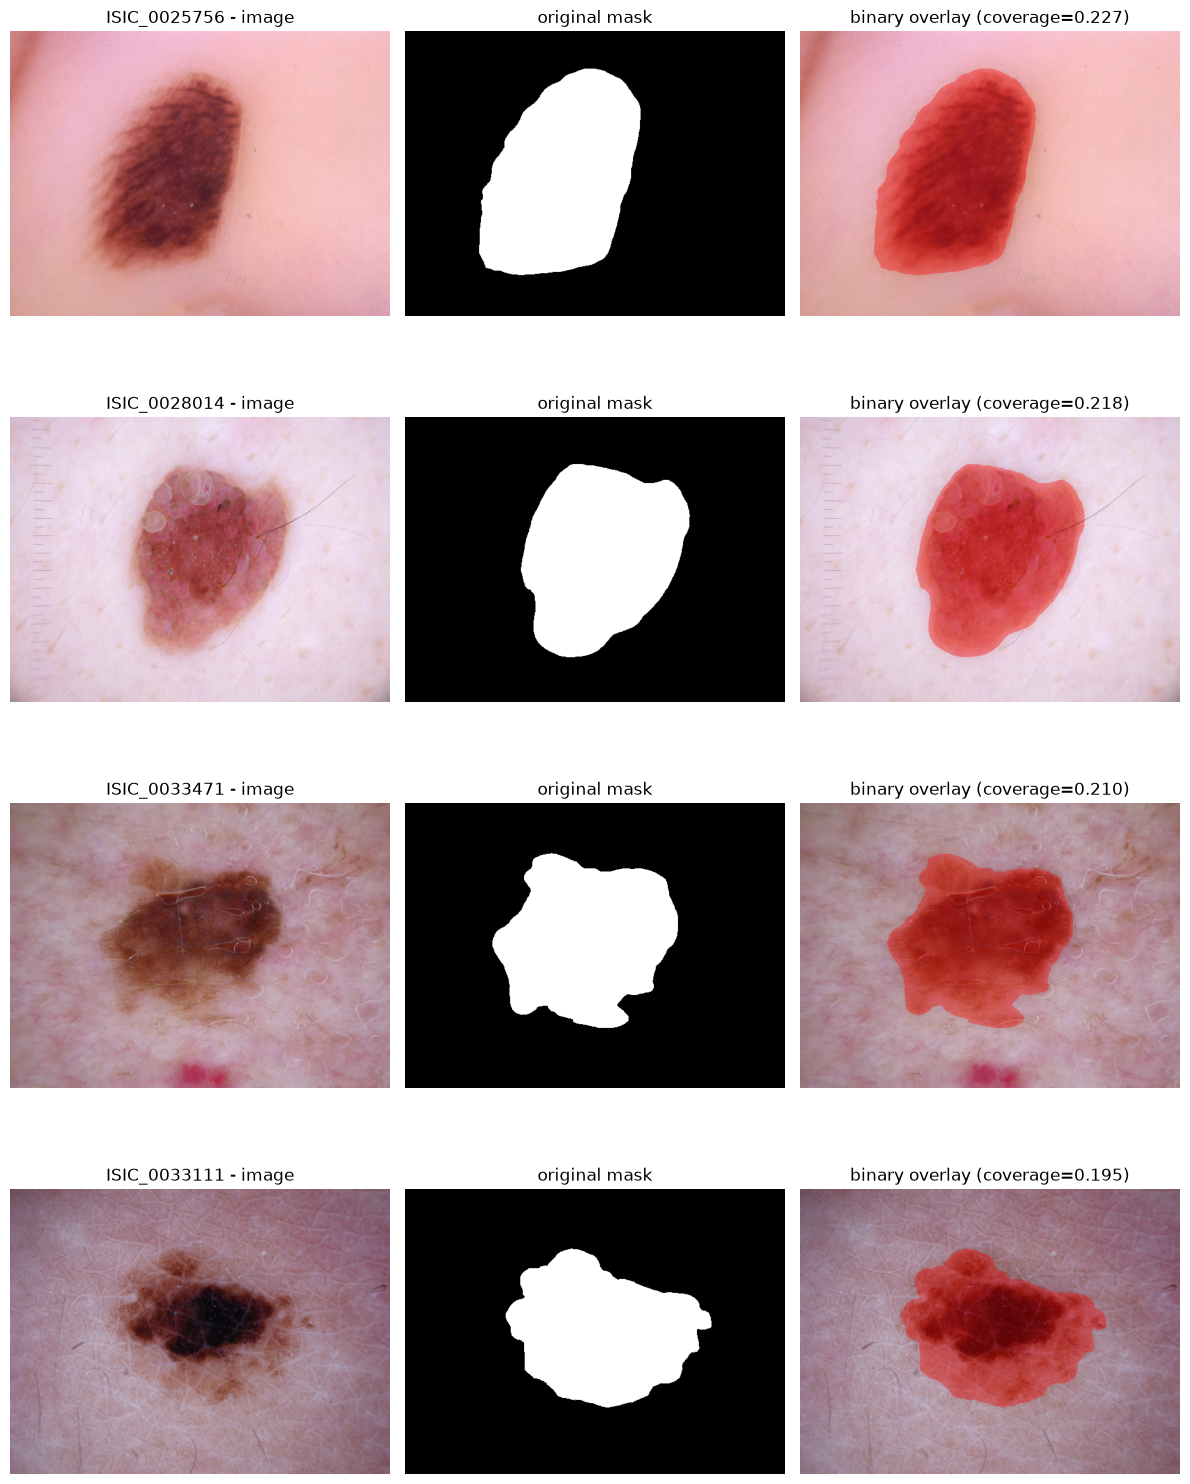

In [16]:
# Visual check on HAM10000
sample_triplet(ham_core, HAM_IMG_DIR, HAM_MASK_DIR, n=4, random_state=7)


## 4. Resizing strategy

For the baseline CNN we use:
- **bilinear interpolation** for RGB images
- **nearest-neighbor interpolation** for binary masks

Nearest-neighbor must be used for masks to avoid creating artificial gray values on boundaries.

Note: we prefer to resize images and masks to 224x224 for compatibility with common pretrained models and to reduce memory usage during training.

All geometric features later in the pipeline (e.g. feature extraction, classification, lesion diameter) will be based on these resized versions. 
Therefore they represent relative rather than absolute physical measurements, but this is acceptable for our classification task.
Resizing changes absolute geometry, but not relative structure; diameter becomes relative (pixel-based); pseudo-concepts still work correctly.
The only caveat is aspect ratio distortion. 

However using 224x224 ratio for all model input, masks, saliency, pseudo-concepts, metrics will not cause any issues, as all will be resized to the same dimensions.
 
For visualisation, we can still use the original aspect ratio images and masks, as they are only for qualitative assessment and not used in the model training or evaluation.


In [17]:
def show_resized_examples(df: pd.DataFrame, img_dir: Path, mask_dir: Path, n: int = 3, size=(224, 224), random_state: int = 42):
    sample = df.sample(min(n, len(df)), random_state=random_state)
    fig, axes = plt.subplots(len(sample), 4, figsize=(15, 4 * len(sample)))

    if len(sample) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(sample.iterrows()):
        stem = row["stem"]
        img = load_rgb(img_dir / f"{stem}.jpg")
        mask = to_mask_bin(load_mask_gray(mask_dir / f"{stem}.png"))

        img_resized = resize_image_rgb(img, size=size)
        mask_resized = resize_mask_bin(mask, size=size)
        overlay_resized = overlay_mask(img_resized, mask_resized)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{stem} - original image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("original mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(img_resized)
        axes[i, 2].set_title(f"resized image {size}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay_resized)
        axes[i, 3].set_title("resized overlay")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


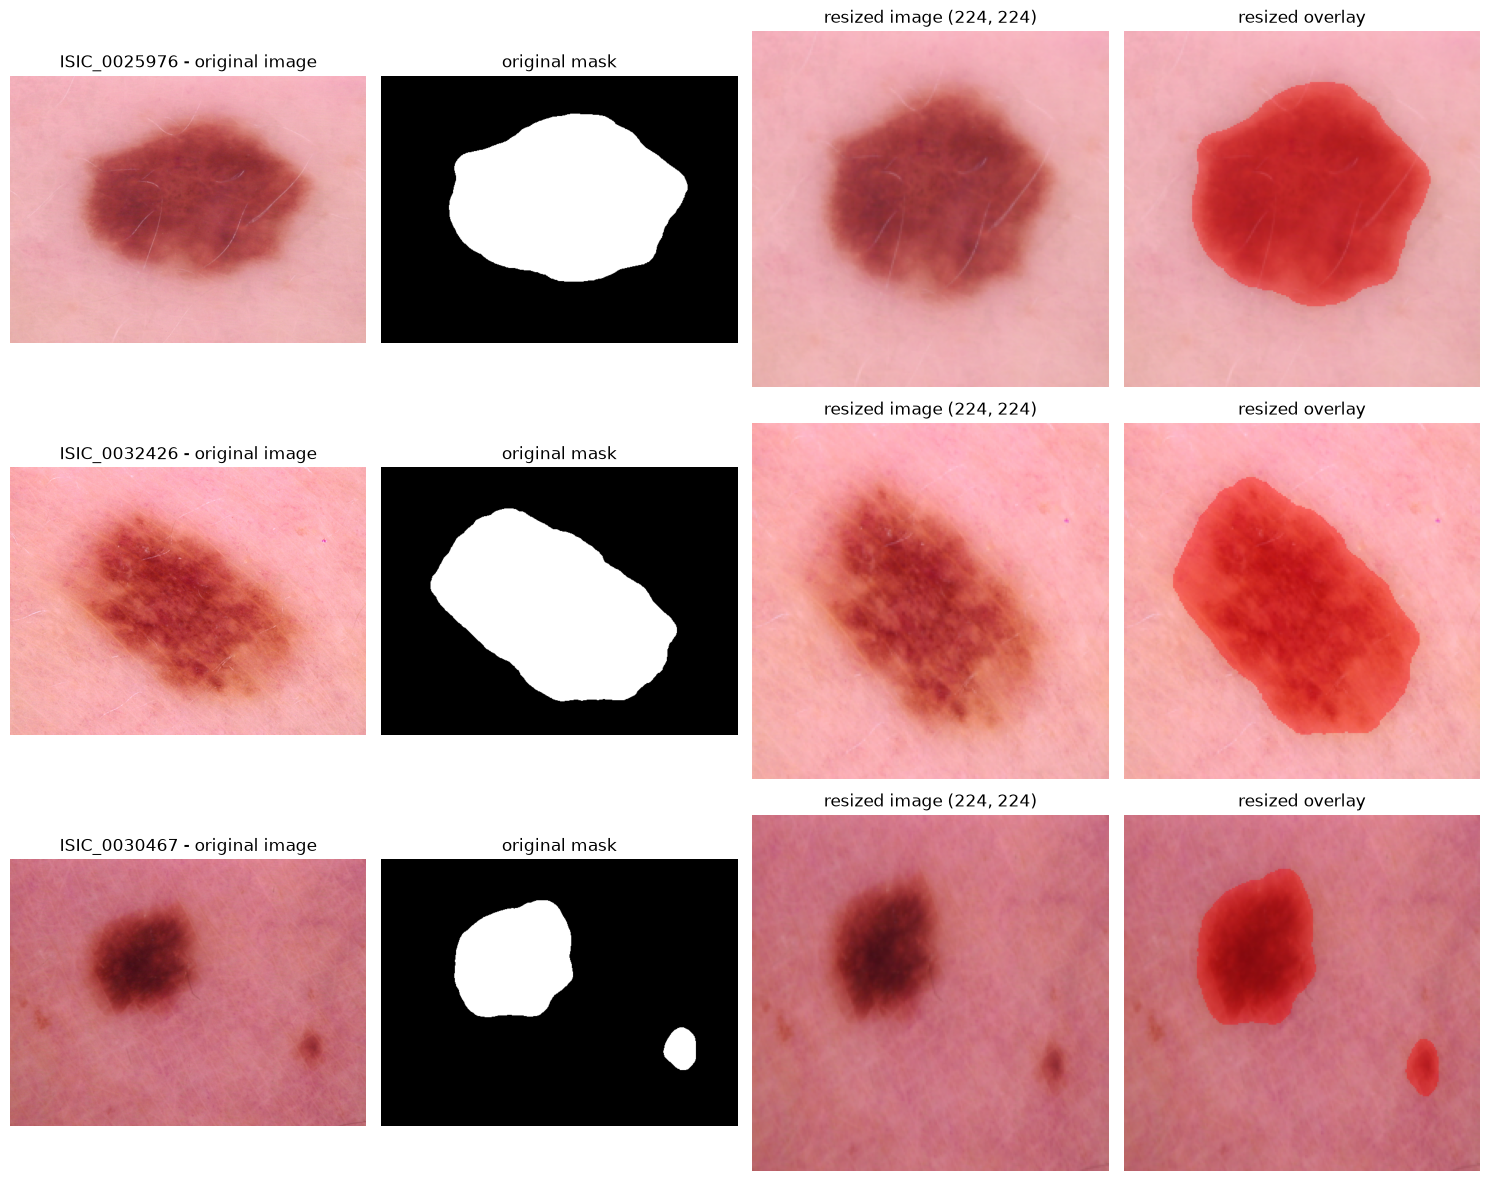

In [18]:
show_resized_examples(ham_core, HAM_IMG_DIR, HAM_MASK_DIR, n=3, size=(224, 224), random_state=11)


## 5. Normalisation strategy

For the ResNet-50 baseline we use standard **ImageNet normalisation** after scaling RGB values to `[0, 1]`.

This notebook defines the logic and performs a quick sanity check. The actual tensor conversion can be handled later in the training notebook.


In [19]:
# Quick normalisation sanity check on one image
example_stem = ham_core.iloc[0]["stem"]
example_img = load_rgb(HAM_IMG_DIR / f"{example_stem}.jpg")
example_img_224 = resize_image_rgb(example_img, size=(224, 224))
example_norm = normalize_imagenet(example_img_224)

print("Original dtype:", example_img_224.dtype)
print("Normalised dtype:", example_norm.dtype)
print("Normalised shape:", example_norm.shape)
print("Channel-wise min:", example_norm.min(axis=(0, 1)))
print("Channel-wise max:", example_norm.max(axis=(0, 1)))
print("Channel-wise mean:", example_norm.mean(axis=(0, 1)))


Original dtype: uint8
Normalised dtype: float32
Normalised shape: (224, 224, 3)
Channel-wise min: [-0.79929787 -1.7380952  -1.3861438 ]
Channel-wise max: [2.0947855  0.71288526 1.1410894 ]
Channel-wise mean: [1.5596176  0.02360365 0.26023874]


## 6. Lesion geometry extraction

We derive a small set of lesion-level geometric descriptors directly from the binary mask:

- `mask_pixels`
- `mask_coverage`
- `equivalent_diameter_px`
- `centroid_x`, `centroid_y`
- bounding box coordinates and dimensions

These features are useful later for:
- analysing lesion size effects on XAI metrics
- generating pseudo-concept regions
- cropping or centering experiments


In [20]:
def extract_geometry_from_mask(mask_bin: np.ndarray) -> dict:
    ys, xs = np.where(mask_bin > 0)

    area = int(mask_bin.sum())

    if area == 0:
        return {
            "mask_pixels": 0,
            "mask_coverage": 0.0,
            "equivalent_diameter_px": 0.0,
            "centroid_x": np.nan,
            "centroid_y": np.nan,
            "bbox_xmin": np.nan,
            "bbox_ymin": np.nan,
            "bbox_xmax": np.nan,
            "bbox_ymax": np.nan,
            "bbox_width": np.nan,
            "bbox_height": np.nan,
        }

    y_min, y_max = int(ys.min()), int(ys.max())
    x_min, x_max = int(xs.min()), int(xs.max())

    h, w = mask_bin.shape
    coverage = area / float(h * w)
    eq_diameter = float(np.sqrt(4.0 * area / np.pi))
    cx = float(xs.mean())
    cy = float(ys.mean())

    return {
        "mask_pixels": area,
        "mask_coverage": coverage,
        "equivalent_diameter_px": eq_diameter,
        "centroid_x": cx,
        "centroid_y": cy,
        "bbox_xmin": x_min,
        "bbox_ymin": y_min,
        "bbox_xmax": x_max,
        "bbox_ymax": y_max,
        "bbox_width": x_max - x_min + 1,
        "bbox_height": y_max - y_min + 1,
    }


In [21]:
def enrich_with_geometry(df: pd.DataFrame, mask_dir: Path) -> pd.DataFrame:
    records = []

    for _, row in df.iterrows():
        stem = row["stem"]
        mask_path = mask_dir / f"{stem}.png"
        mask_bin = to_mask_bin(load_mask_gray(mask_path))
        geom = extract_geometry_from_mask(mask_bin)
        geom["stem"] = stem
        records.append(geom)

    geom_df = pd.DataFrame(records)
    return df.merge(geom_df, on="stem", how="left")


In [22]:
## Note this takes a few minutes to run as it processes all images and masks to extract geometry features.
isic_pre = enrich_with_geometry(isic_core, ISIC_MASK_DIR)
ham_pre = enrich_with_geometry(ham_core, HAM_MASK_DIR)

display(isic_pre.head())
display(ham_pre.head())


,stem,image_exists,mask_exists,img_h,img_w,pixels,aspect_ratio,mask_h,mask_w,mask_coverage_x,mask_pixels_x,mask_size_class,same_size,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched,mask_pixels_y,mask_coverage_y,equivalent_diameter_px,centroid_x,centroid_y,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax,bbox_width,bbox_height
0,ISIC_0000000,True,True,767,1022,783874,1.332464,767,1022,0.469732,368211,normal,True,False,False,False,False,False,0,368211,0.469732,684.704904,499.114768,366.873355,49,46,900,635,852,590
1,ISIC_0000001,True,True,767,1022,783874,1.332464,767,1022,0.070504,55266,normal,True,False,False,False,False,False,0,55266,0.070504,265.267519,500.333297,357.570333,351,229,649,482,299,254
2,ISIC_0000003,True,True,767,1022,783874,1.332464,767,1022,0.336569,263828,normal,True,False,False,False,False,False,0,263828,0.336569,579.582818,537.751202,357.124763,251,49,849,700,599,652
3,ISIC_0000004,True,True,767,1022,783874,1.332464,767,1022,0.344974,270416,normal,True,False,False,False,False,False,0,270416,0.344974,586.774526,452.629733,371.571863,181,57,719,718,539,662
4,ISIC_0000006,True,True,767,1022,783874,1.332464,767,1022,0.091723,71899,normal,True,False,False,False,False,False,0,71899,0.091723,302.563464,478.021447,361.087790,333,191,625,540,293,350


,stem,image_exists,mask_exists,img_h,img_w,pixels,aspect_ratio,mask_h,mask_w,mask_coverage_x,mask_pixels_x,mask_size_class,same_size,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched,lesion_id,dx,label,label_name,mask_pixels_y,mask_coverage_y,equivalent_diameter_px,centroid_x,centroid_y,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax,bbox_width,bbox_height
0,ISIC_0024306,True,True,450,600,270000,1.333333,450,600,0.342774,92549,normal,True,False,False,False,False,False,0,HAM_0000550,nv,0,non-melanoma,92549,0.342774,343.274011,330.463484,214.999254,180,7,507,418,328,412
1,ISIC_0024307,True,True,450,600,270000,1.333333,450,600,0.416826,112543,normal,True,False,False,False,False,False,0,HAM_0003577,nv,0,non-melanoma,112543,0.416826,378.542201,334.866478,238.257697,146,34,524,429,379,396
2,ISIC_0024308,True,True,450,600,270000,1.333333,450,600,0.370004,99901,normal,True,False,False,False,False,False,0,HAM_0001477,nv,0,non-melanoma,99901,0.370004,356.648151,303.521897,245.204342,61,66,544,433,484,368
3,ISIC_0024309,True,True,450,600,270000,1.333333,450,600,0.356407,96230,normal,True,False,True,False,False,True,1,HAM_0000484,nv,0,non-melanoma,96230,0.356407,350.034057,245.200540,286.978655,72,115,436,449,365,335
4,ISIC_0024310,True,True,450,600,270000,1.333333,450,600,0.240785,65012,normal,True,False,False,False,False,False,0,HAM_0003350,mel,1,melanoma,65012,0.240785,287.707924,293.555851,208.784394,72,78,469,349,398,272


In [23]:
print("ISIC geometry summary:")
display(isic_pre[[
    "mask_pixels_x", "mask_coverage_x", "equivalent_diameter_px",
    "bbox_width", "bbox_height"
]].describe())

print("HAM geometry summary:")
display(ham_pre[[
    "mask_pixels_x", "mask_coverage_x", "equivalent_diameter_px",
    "bbox_width", "bbox_height"
]].describe())


ISIC geometry summary:


,mask_pixels_x,mask_coverage_x,equivalent_diameter_px,bbox_width,bbox_height
count,2.594000e+03,2594.000000,2594.000000,2594.000000,2594.000000
mean,2.101907e+06,0.214021,1181.467882,1326.978412,1166.669237
std,4.266791e+06,0.208366,1131.750023,1331.217430,1045.907086
min,9.575000e+03,0.002977,110.414078,118.000000,101.000000
25%,1.918715e+05,0.051731,494.265485,535.250000,502.250000
50%,4.236360e+05,0.138084,734.431826,811.000000,750.000000
75%,1.398957e+06,0.318733,1334.618505,1437.250000,1381.500000
max,2.803354e+07,0.986650,5974.395920,6708.000000,4479.000000


HAM geometry summary:


,mask_pixels_x,mask_coverage_x,equivalent_diameter_px,bbox_width,bbox_height
count,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000
mean,71907.687169,0.266325,282.918702,317.886470,278.728407
std,50873.050488,0.188419,107.302697,133.657768,100.710166
min,1041.000000,0.003856,36.406625,37.000000,35.000000
25%,32266.000000,0.119504,202.687807,215.000000,202.000000
50%,60023.000000,0.222307,276.448290,302.000000,277.000000
75%,101017.500000,0.374139,358.635573,410.500000,360.000000
max,270000.000000,1.000000,586.323014,600.000000,450.000000


In [24]:
# ============================================================
# Combined lesion-size distribution: HAM10000 + ISIC2018

import pandas as pd

SIZE_ORDER = [
    "normal",
    "small",
    "tiny",
    "very_tiny",
]

SIZE_LABELS = {
    "normal": "Normal",
    "small": "Small",
    "tiny": "Tiny",
    "very_tiny": "Very Tiny",
}

combined = pd.concat(
    [
        ham_pre.assign(dataset="HAM10000"),
        isic_pre.assign(dataset="ISIC2018"),
    ],
    ignore_index=True
)

combined["mask_size_class"] = (
    combined["mask_size_class"]
    .astype(str)
    .str.strip()
    .str.lower()
)

total_n = len(combined)

scale_table = (
    combined["mask_size_class"]
    .value_counts()
    .reindex(SIZE_ORDER, fill_value=0)
    .rename_axis("mask_size_class")
    .reset_index(name="Count")
)

scale_table["Scale Tier"] = (
    scale_table["mask_size_class"]
    .map(SIZE_LABELS)
)

scale_table["Dataset %"] = (
    100 * scale_table["Count"] / total_n
).round(1)

scale_table = scale_table[
    ["Scale Tier", "Count", "Dataset %"]
]

display(scale_table)

,Scale Tier,Count,Dataset %
0,Normal,11254,89.3
1,Small,971,7.7
2,Tiny,285,2.3
3,Very Tiny,99,0.8


In [25]:
# ============================================================
# Combined border-touch prevalence: HAM10000 + ISIC2018


border_cols = [
    "touch_top",
    "touch_bottom",
    "touch_left",
    "touch_right",
    "touches_any_border",
]

# Ensure Boolean values
for col in border_cols:
    if combined[col].dtype != bool:
        combined[col] = (
            combined[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            })
        )

border_table = pd.DataFrame({
    "Border Condition": [
        "Top",
        "Bottom",
        "Left",
        "Right",
        "Any Border",
    ],
    "Count": [
        combined["touch_top"].sum(),
        combined["touch_bottom"].sum(),
        combined["touch_left"].sum(),
        combined["touch_right"].sum(),
        combined["touches_any_border"].sum(),
    ],
})

border_table["Dataset %"] = (
    100 * border_table["Count"] / len(combined)
).round(1)

display(border_table)

,Border Condition,Count,Dataset %
0,Top,948,7.5
1,Bottom,983,7.8
2,Left,549,4.4
3,Right,505,4.0
4,Any Border,1800,14.3


## 7. Visual geometry sanity check


In [26]:
def show_geometry_examples(df: pd.DataFrame, img_dir: Path, mask_dir: Path, n: int = 4, random_state: int = 42):
    sample = df.sample(min(n, len(df)), random_state=random_state)
    fig, axes = plt.subplots(len(sample), 2, figsize=(11, 4 * len(sample)))

    if len(sample) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(sample.iterrows()):
        stem = row["stem"]
        img = load_rgb(img_dir / f"{stem}.jpg")
        mask = to_mask_bin(load_mask_gray(mask_dir / f"{stem}.png"))
        overlay = overlay_mask(img, mask)

        x0, y0 = int(row["bbox_xmin"]), int(row["bbox_ymin"])
        bw, bh = int(row["bbox_width"]), int(row["bbox_height"])

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{stem} - original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(overlay)
        rect = plt.Rectangle((x0, y0), bw, bh, fill=False, edgecolor="yellow", linewidth=2)
        axes[i, 1].add_patch(rect)
        axes[i, 1].scatter(row["centroid_x"], row["centroid_y"], s=25, c="cyan")
        axes[i, 1].set_title(
            f"overlay | eq_diam={row['equivalent_diameter_px']:.1f}px | coverage={row['mask_coverage_x']:.3f}"
        )
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


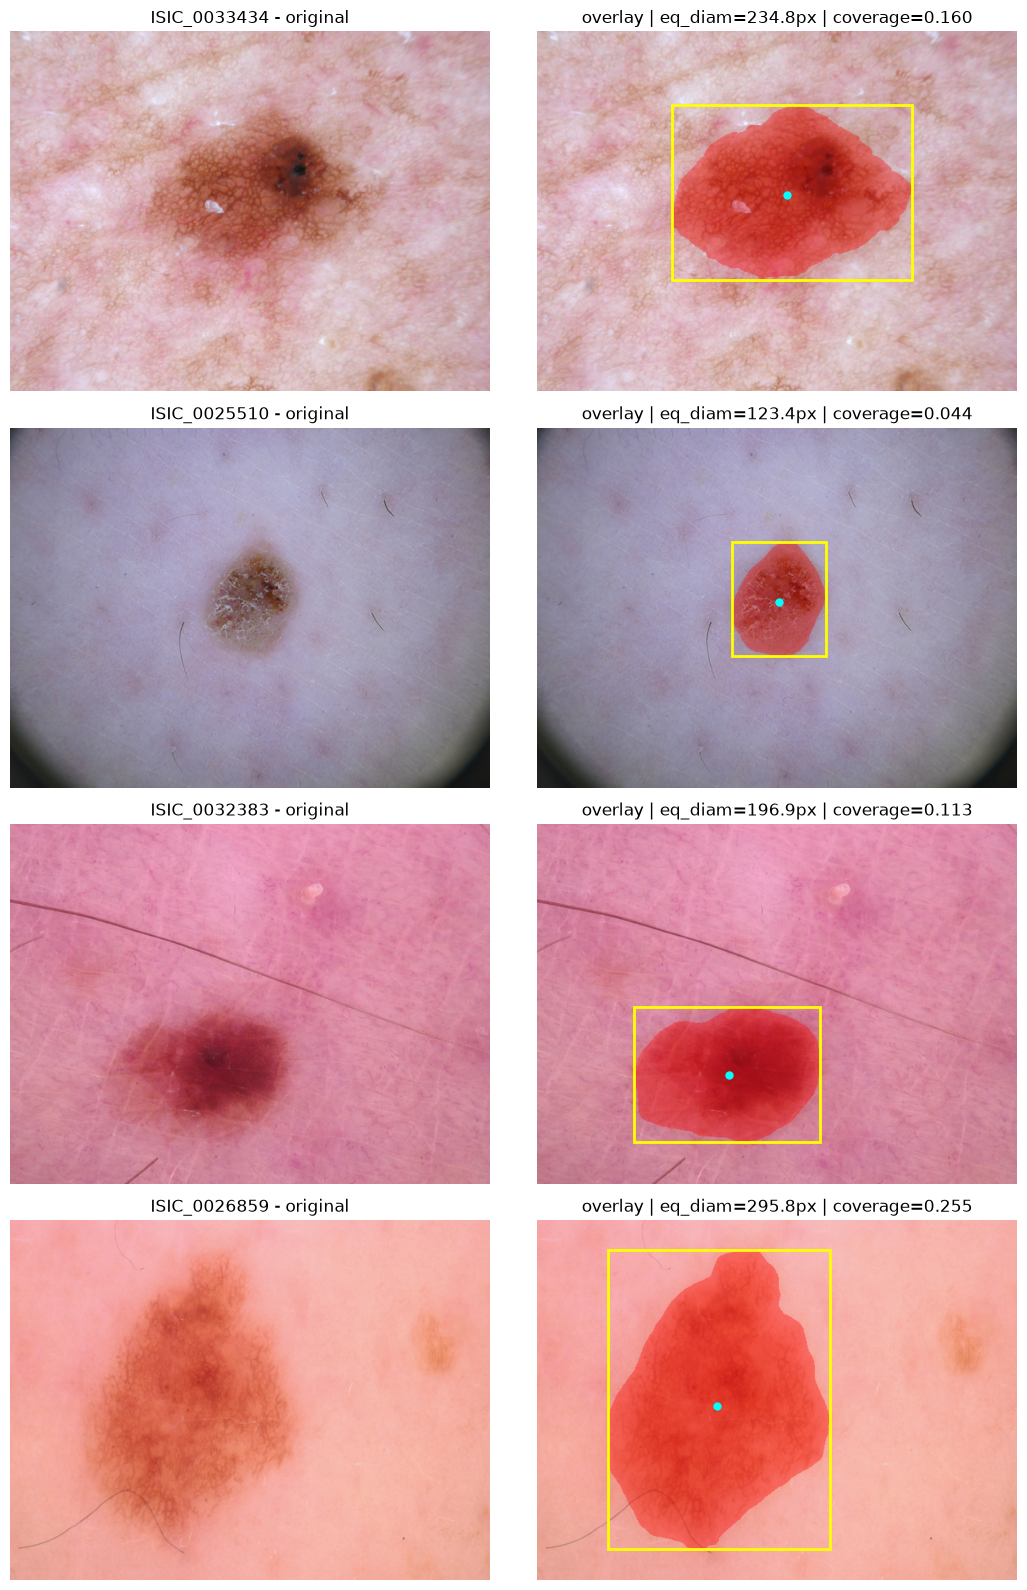

In [27]:
show_geometry_examples(ham_pre, HAM_IMG_DIR, HAM_MASK_DIR, n=4, random_state=21)


## 8. Save enriched preprocessing manifests

We export enriched manifests that can be reused later by:
- the training notebook
- the XAI notebook
- the pseudo-concept generation notebook


In [28]:

isic_out = OUT_DIR / "isic2018_preprocessed.csv"
ham_out = OUT_DIR / "ham10000_preprocessed.csv"

# lesion_id is carried through enrich_with_geometry because the geometry
# table is merged back onto the complete source manifest by stem.
assert "lesion_id" in ham_pre.columns
assert ham_pre["lesion_id"].notna().all()

isic_pre.to_csv(isic_out, index=False)
ham_pre.to_csv(ham_out, index=False)

print("Saved:", isic_out.resolve())
print("Saved:", ham_out.resolve())
print("ISIC rows:", len(isic_pre))
print("HAM rows :", len(ham_pre))
print("HAM unique lesions:", ham_pre["lesion_id"].nunique())


Saved: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/preprocessed_manifests/isic2018_preprocessed.csv
Saved: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/preprocessed_manifests/ham10000_preprocessed.csv
ISIC rows: 2594
HAM rows : 10015
HAM unique lesions: 7470


## Summary

This notebook completed the **core preprocessing definition** for DermaXplain:

- loaded and filtered inventory manifests
- confirmed binary mask conversion
- defined resizing rules for images and masks
- defined ImageNet normalization for CNN input
- extracted lesion geometry descriptors in pixel space
- exported enriched preprocessing manifests

### Next notebooks

- `01_preprocessing_experiments.ipynb` for optional branches such as cropping, hair removal, and color normalization
- `02_model_baseline_resnet50.ipynb` for CNN training
